# Proyecto Integrador — Machine Learning  
## Módulo: Machine Learning | Soy Henry

**Estudiante:** Vanina Cavallin  
**Proyecto:** Predicción de Churn de Clientes  
**Empresa ficticia:** FinanceGuard  
**Avance:** Nº 2 — Integración y Cierre  

**Fecha:** 09/02/2026  

---

# Consigna:

Comparar los resultados de la ejecución de los algoritmos de Random Forest, Gradient Boosting (xGBoost, LightGBM, y CatBoost), y un ensamble de modelos (Stacking). Aplicar optimización de hiperparámetros solamente al modelo XGBoost utilizando Grid Search. La optimización utilizando Optuna es opcional, siendo bueno mencionar que hoy en día es ampliamente utilizada. Es caso de decidir hacerla utilizar 50 trials.

## 1) Importación de librerías

In [4]:
# Importar librerías necesarias
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    roc_auc_score, average_precision_score
)

## 2) Carga del dataset

In [5]:
df = pd.read_csv("Churn_Modelling.csv")
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## 3) Selección de **features** y **target**

In [6]:
# Definir X / y
target = "Exited"
drop_cols = ["RowNumber", "CustomerId", "Surname"]

X = df.drop(columns=[target] + drop_cols)
y = df[target]

# Definir columnas categóricas y numéricas
categorical_cols = ["Geography", "Gender"]
numeric_cols = [c for c in X.columns if c not in categorical_cols]
X.head(), 
y.value_counts(normalize=True)

# Averiguamos la proporción de los datos

Exited
0    0.7963
1    0.2037
Name: proportion, dtype: float64

## 4) Preprocesamiento robusto: OneHot con manejo de categorías nuevas

**Objetivo:**  
Evitar errores cuando aparecen categorías no vistas durante el entrenamiento.

**Qué hace este bloque:**  
- Aplica OneHotEncoding a categóricas con `handle_unknown="ignore"` (no falla si aparece una categoría nueva en test).
- Mantiene numéricas con `passthrough`.
- Descarta columnas no especificadas (`remainder="drop"`).

**Output:**  
- `preprocessor`: listo para integrarse en pipelines.

In [7]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols)
    ],
    remainder="drop"
)

## 5) División Train/Test (estratificada)

**Objetivo:**  
Separar un conjunto de test “limpio” para evaluar generalización.

**Qué hace este bloque:**  
- Divide el dataset en 80% train y 20% test.
- Usa `stratify=y` para conservar la proporción de clases (importante en churn/desbalance).
- Fija `random_state=42` para reproducibilidad.

**Outputs:**  
- `X_train`, `X_test`, `y_train`, `y_test`

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

## 6) Validación cruzada y función de evaluación (ROC-AUC + PR-AUC)

**Objetivo:**  
Estandarizar la comparación de modelos usando métricas adecuadas para desbalance.

**Qué hace este bloque:**  
- Define una CV estratificada de 5 folds.
- Crea `evaluate_classifier()` que:
  - Predice clases (`predict`)
  - Obtiene probabilidades/scores (`predict_proba` o `decision_function`)
  - Calcula Accuracy, Precision, Recall, ROC-AUC y PR-AUC.

**Output:**  
- `cv`: estrategia de cross-validation
- `evaluate_classifier`: función reusable para medir modelos

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def evaluate_classifier(model, X_te, y_te):
    """
    Devuelve métricas estándar + ROC-AUC y PR-AUC (clave en desbalance).
    """
    y_pred = model.predict(X_te)

    # Para PR-AUC y ROC-AUC necesitamos probabilidades:
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_te)[:, 1]
    else:
        # fallback raro (por compatibilidad)
        y_proba = model.decision_function(X_te)

    return {
        "Accuracy": accuracy_score(y_te, y_pred),
        "Precision": precision_score(y_te, y_pred, zero_division=0),
        "Recall": recall_score(y_te, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_te, y_proba),
        "PR-AUC": average_precision_score(y_te, y_proba)
    }

## 7) Modelos base en Pipeline (preprocesamiento + modelo)

**Objetivo:**  
Entrenar y comparar modelos fuertes de clasificación (RF, XGB, LGBM) con un flujo consistente.

**Qué hace este bloque:**  
- Construye pipelines que incluyen:
  - `preprocessor` (OHE + numéricas)
  - el modelo (RF / XGB / LGBM)
- Evita data leakage al aprender el OneHot sólo con train dentro del pipeline.

**Outputs:**  
- `rf_pipeline`, `xgb_pipeline`, `lgbm_pipeline`

In [10]:
# RandomForest
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    ))
])

# XGBClassifier
from xgboost import XGBClassifier

xgb_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ))
])

# LGBMClassifier
from lightgbm import LGBMClassifier

lgbm_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        min_data_in_leaf=20,
        random_state=42,
        n_jobs=-1
    ))
])

## 8) CatBoostWrapper: CatBoost compatible con scikit-learn (para Stacking)

**Objetivo:**  
Poder usar **CatBoost** como modelo base dentro de `StackingClassifier` de scikit-learn, manteniendo la interfaz estándar (`fit`, `predict`, `predict_proba`) y pasando correctamente las variables categóricas (`cat_features`).

**Contexto (por qué hace falta):**  
CatBoost maneja categóricas de forma nativa, pero scikit-learn exige que los modelos usados en ensembles (como Stacking) sean **"sklearn-compatible"** (clonables y con API uniforme).  
Este wrapper actúa como un “adaptador” entre CatBoost y scikit-learn.

---

### Qué hace este bloque (paso a paso)
1. **Importa**:
   - `CatBoostClassifier`: modelo de gradient boosting con soporte nativo de categóricas.
   - `BaseEstimator`, `ClassifierMixin`: clases base para que el wrapper cumpla la API sklearn.

2. **Define `CatBoostWrapper`**:
   - Guarda hiperparámetros en `__init__` (iterations, learning_rate, depth, etc.).
   - Crea atributos internos:
     - `model_`: el modelo real de CatBoost entrenado.
     - `cat_features_idx_`: índices de columnas categóricas.

3. **En `fit(X, y)`**:
   - Si `X` es un **DataFrame**, detecta los índices de las columnas categóricas usando `categorical_cols`.
   - Instancia `CatBoostClassifier` con los hiperparámetros.
   - Entrena:
     - con `cat_features=...` si se detectaron índices,
     - o sin `cat_features` si no corresponde.

4. **En `predict` y `predict_proba`**:
   - Delegan directamente en el modelo interno (`self.model_`).

---

### Inputs
- `X`: variables predictoras (idealmente `pd.DataFrame` para detectar columnas categóricas).
- `y`: target binario (churn/no churn).
- `categorical_cols`: lista de columnas categóricas definida previamente.

### Outputs
- Un estimador entrenado `CatBoostWrapper` listo para:
  - usarse en `StackingClassifier`,
  - predecir clases (`predict`) y probabilidades (`predict_proba`).

---

### Nota importante
Este enfoque permite aprovechar el **manejo nativo de categóricas** de CatBoost (sin OneHotEncoding), lo cual puede mejorar performance y robustez, especialmente cuando hay variables categóricas relevantes para explicar el churn.

In [11]:
from catboost import CatBoostClassifier
from sklearn.base import BaseEstimator, ClassifierMixin

class CatBoostWrapper(BaseEstimator, ClassifierMixin):
    """
    Wrapper sklearn-compatible para usar CatBoost dentro de StackingClassifier
    pasando cat_features en fit.
    """
    def __init__(self, iterations=300, learning_rate=0.05, depth=6, random_state=42, verbose=0):
        self.iterations = iterations
        self.learning_rate = learning_rate
        self.depth = depth
        self.random_state = random_state
        self.verbose = verbose
        self.model_ = None
        self.cat_features_idx_ = None

    def fit(self, X, y):
        # Detecta índices categóricos según columnas esperadas
        if isinstance(X, pd.DataFrame):
            self.cat_features_idx_ = [X.columns.get_loc(c) for c in categorical_cols]
        else:
            # si viene como array, asumimos que las categóricas están al inicio en orden original
            # (en este notebook usamos DataFrame, así que normalmente no entra acá)
            self.cat_features_idx_ = None

        self.model_ = CatBoostClassifier(
            iterations=self.iterations,
            learning_rate=self.learning_rate,
            depth=self.depth,
            random_state=self.random_state,
            verbose=self.verbose
        )
        if self.cat_features_idx_ is not None:
            self.model_.fit(X, y, cat_features=self.cat_features_idx_)
        else:
            self.model_.fit(X, y)
        return self

    def predict(self, X):
        return self.model_.predict(X)

    def predict_proba(self, X):
        return self.model_.predict_proba(X)


## 9) Inicialización del modelo CatBoost (wrapper)

**Objetivo:**  
Configurar el modelo **CatBoost** con hiperparámetros controlados, listo para ser entrenado y utilizado como modelo base dentro del ensamble de Stacking.

**Qué hace este bloque:**  
- Crea una instancia de `CatBoostWrapper`, que adapta CatBoost a la API de scikit-learn.
- Define los principales hiperparámetros del modelo:
  - `iterations=300`: cantidad de árboles (boosting rounds).
  - `learning_rate=0.05`: tasa de aprendizaje baja para mejorar estabilidad y generalización.
  - `depth=6`: profundidad de los árboles (controla complejidad).
  - `random_state=42`: asegura reproducibilidad.
  - `verbose=0`: desactiva logs durante el entrenamiento.

**Output:**  
- `cat_model`: estimador CatBoost configurado y listo para entrenar.

**Nota:**  
Este modelo se entrenará posteriormente sobre los datos de entrenamiento y será utilizado como **modelo base** en el esquema de Stacking junto con XGBoost y LightGBM.

In [27]:
cat_model = CatBoostWrapper(
    iterations=300,
    learning_rate=0.05,
    depth=6,
    random_state=42,
    verbose=0
)

## 10) Optimización de hiperparámetros (GridSearchCV) para XGBoost

**Objetivo:**  
Encontrar la mejor combinación de hiperparámetros para XGBoost usando CV estratificada.

**Qué hace este bloque:**  
- Define un grid de búsqueda para el paso `model` del pipeline (`model__param`).
- Ejecuta GridSearchCV optimizando **ROC-AUC**.
- Guarda el mejor pipeline entrenable en `best_xgb`.

**Outputs:**  
- `grid_xgb`: objeto de búsqueda
- `best_xgb`: mejor estimador (pipeline completo)
- `grid_xgb.best_params_`, `grid_xgb.best_score_`

In [13]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "model__n_estimators": [200, 300, 500],
    "model__max_depth": [3, 5, 7],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0]
}

grid_xgb = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_xgb.fit(X_train, y_train)

best_xgb = grid_xgb.best_estimator_
grid_xgb.best_params_, grid_xgb.best_score_


Fitting 5 folds for each of 108 candidates, totalling 540 fits


({'model__colsample_bytree': 0.8,
  'model__learning_rate': 0.05,
  'model__max_depth': 3,
  'model__n_estimators': 300,
  'model__subsample': 0.8},
 np.float64(0.8660756421492616))

## 10) Entrenamiento final y comparación de modelos

**Objetivo:**  
Entrenar todos los modelos base sobre el mismo conjunto de entrenamiento y compararlos de forma justa utilizando métricas relevantes para el problema de **churn de clientes**.

---

### Qué hace este bloque

1. **Entrenamiento de modelos base**
   - Ajusta los siguientes modelos usando `X_train` y `y_train`:
     - Random Forest
     - XGBoost (baseline)
     - LightGBM
     - CatBoost
   - Cada modelo se entrena con el mismo split y el mismo preprocesamiento, garantizando comparabilidad.

2. **Evaluación en conjunto de test**
   - Se utiliza la función `evaluate_classifier()` para calcular:
     - Accuracy
     - Precision
     - Recall
     - ROC-AUC
     - PR-AUC
   - La evaluación se realiza sobre `X_test`, un conjunto no visto durante el entrenamiento.

3. **Comparación estructurada de resultados**
   - Se consolidan las métricas en un `DataFrame` llamado `results`.
   - Cada fila representa un modelo distinto.
   - Se ordenan los resultados por **ROC-AUC** para identificar el mejor desempeño global.

---

### Outputs
- `results`: tabla comparativa de métricas por modelo, ordenada por capacidad discriminativa.
- Base cuantitativa para decidir qué modelo:
  - detectar mejor clientes con riesgo de abandono,
  - usar como input para el ensamble de Stacking.

---

### Interpretación orientada al negocio
- Modelos con **mayor PR-AUC** son más efectivos para focalizar campañas de retención.
- Modelos con **mejor Recall** reducen el riesgo de perder clientes valiosos (falsos negativos).
- Esta comparación permite balancear:
  - costo de contactar clientes innecesariamente,
  - versus costo de perder clientes por no anticipar el churn.

📌 **Conclusión parcial:**  
Este bloque permite identificar los modelos más prometedores para producción y seleccionar los mejores candidatos para el ensamble de Stacking.

In [ ]:
# Fit modelos base
rf_pipeline.fit(X_train, y_train)
xgb_pipeline.fit(X_train, y_train)
lgbm_pipeline.fit(X_train, y_train)
cat_model.fit(X_train, y_train)

# Métricas
rf_metrics = evaluate_classifier(rf_pipeline, X_test, y_test)
xgb_base_metrics = evaluate_classifier(xgb_pipeline, X_test, y_test)
xgb_grid_metrics = evaluate_classifier(best_xgb, X_test, y_test)
lgbm_metrics = evaluate_classifier(lgbm_pipeline, X_test, y_test)
cat_metrics = evaluate_classifier(cat_model, X_test, y_test)

results = pd.DataFrame.from_dict({
    "Random Forest": rf_metrics,
    "XGBoost (baseline)": xgb_base_metrics,
    "XGBoost (GridSearch)": xgb_grid_metrics,
    "LightGBM": lgbm_metrics,
    "CatBoost": cat_metrics,
}, orient="index")

results.sort_values("ROC-AUC", ascending=False)

[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Number of positive: 1630, number of negative: 6370
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000902 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 857
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.203750 -> initscore=-1.363019
[LightGBM] [Info] Start training from score -1.363019
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ig

c:\Users\vanin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\vanin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,Accuracy,Precision,Recall,ROC-AUC,PR-AUC
CatBoost,0.8710,0.801619,0.486486,0.870953,0.725729
XGBoost (GridSearch),0.8685,0.790323,0.481572,0.869685,0.721618
Random Forest,0.8675,0.819820,0.447174,0.863961,0.708491
XGBoost (baseline),0.8690,0.779923,0.496314,0.860805,0.711004
LightGBM,0.8555,0.715328,0.481572,0.857633,0.694830


## 12) Interpretabilidad: nombres de features + Feature Importance (XGBoost optimizado)

**Objetivo:**  
Interpretar el modelo identificando qué variables (incluyendo dummies) aportan más.

**Qué hace este bloque:**  
- Reconstruye los nombres de columnas resultantes del `ColumnTransformer` (OneHot + passthrough).
- Extrae `feature_importances_` del XGBoost optimizado (`best_xgb`).
- Genera un ranking Top 20 de variables más influyentes.

**Outputs:**  
- `feature_names`: nombres post-transformación
- `fi`: DataFrame ordenado con importancias


In [15]:
def get_feature_names_from_column_transformer(ct: ColumnTransformer):
    """
    Recupera nombres de features tras OneHot + passthrough.
    """
    feature_names = []

    for name, trans, cols in ct.transformers_:
        if name == "remainder" and trans == "drop":
            continue

        if hasattr(trans, "get_feature_names_out"):
            fn = list(trans.get_feature_names_out(cols))
            feature_names.extend(fn)
        elif trans == "passthrough":
            feature_names.extend(cols)
        else:
            # Caso raro: transformador sin nombres
            feature_names.extend(cols)

    return feature_names

In [16]:
import matplotlib.pyplot as plt

xgb_model = best_xgb.named_steps["model"]
ct = best_xgb.named_steps["preprocess"]

feature_names = get_feature_names_from_column_transformer(ct)
importances = xgb_model.feature_importances_

fi = (pd.DataFrame({"feature": feature_names, "importance": importances})
        .sort_values("importance", ascending=False)
        .head(20))

fi

,feature,importance
7,NumOfProducts,0.245490
4,Age,0.199595
9,IsActiveMember,0.174595
0,Geography_Germany,0.112350
2,Gender_Male,0.062587
6,Balance,0.056490
1,Geography_Spain,0.040298
3,CreditScore,0.028986
8,HasCrCard,0.028587
10,EstimatedSalary,0.025870


## 13) Visualización: Top 20 Feature Importances (XGBoost)

**Objetivo:**  
Mostrar de forma visual cuáles son las variables más importantes del modelo optimizado.

**Qué hace este bloque:**  
- Grafica un barplot horizontal con el Top 20 de importancias.
- Ordena para que la variable más importante quede arriba.

**Output:**  
- Gráfico interpretativo para el reporte/defensa

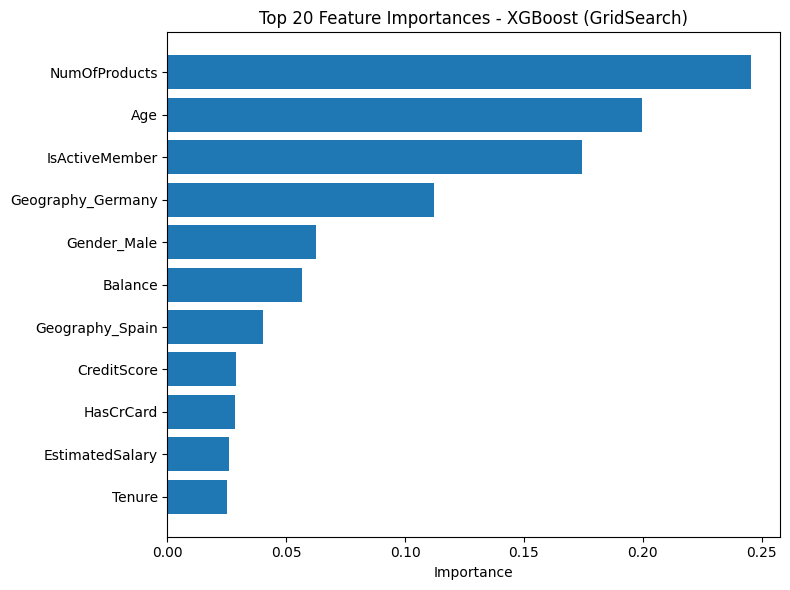

In [ ]:
plt.figure(figsize=(8, 6))
plt.barh(fi["feature"][::-1], fi["importance"][::-1])
plt.title("Top 20 Feature Importances - XGBoost (GridSearch)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## 14) Feature Importance en XGBoost usando **GAIN**

**Objetivo:**  
Interpretar el modelo optimizado identificando qué variables aportan más a la mejora del entrenamiento.

**Qué hace este bloque:**  
- Extrae el `Booster` interno de XGBoost.
- Calcula la importancia por **GAIN** (mejora promedio en la función objetivo al splittear con esa feature).
- Ordena y muestra el Top 20.

**Output:**  
- `gain_df`: ranking de features según GAIN (Top 20).

**Nota:**  
Si aparecen features como `f0`, `f1`, ... es porque el modelo no conserva nombres; se puede mapear con los nombres post-OneHot del `ColumnTransformer`.


In [ ]:
booster = xgb_model.get_booster()
gain_dict = booster.get_score(importance_type="gain")

gain_df = (pd.DataFrame(gain_dict.items(), columns=["feature", "gain"])
             .sort_values("gain", ascending=False)
             .head(20))
gain_df

,feature,gain
7,f7,34.387470
4,f4,27.958651
9,f9,24.456806
0,f0,15.737695
2,f2,8.767066
6,f6,7.912885
1,f1,5.644763
3,f3,4.060308
8,f8,4.004373
10,f10,3.623798


## 15) CatBoost wrapper: compatibilidad total con scikit-learn (requerido para Stacking)

**Objetivo:**  
Garantizar que CatBoost funcione dentro de `StackingClassifier` respetando la API de sklearn.

**Qué hace este bloque:**  
- Define `CatBoostWrapper` con métodos `fit`, `predict`, `predict_proba`.
- En `fit`:
  - Guarda `classes_` (requisito habitual en sklearn).
  - Detecta índices de variables categóricas si `X` es DataFrame.
  - Entrena `CatBoostClassifier` pasando `cat_features`.
- Incluye `thread_count` como control de paralelismo.

**Output:**  
- Clase `CatBoostWrapper` lista para usar en stacking.


In [20]:
import numpy as np
from sklearn.base import BaseEstimator, ClassifierMixin
from catboost import CatBoostClassifier

class CatBoostWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, iterations=300, learning_rate=0.05, depth=6,
                 random_state=42, verbose=0, thread_count=None):
        self.iterations = iterations
        self.learning_rate = learning_rate
        self.depth = depth
        self.random_state = random_state
        self.verbose = verbose
        self.thread_count = thread_count

        # atributos que sklearn espera post-fit
        self.classes_ = None
        self.model_ = None
        self.cat_features_idx_ = None

    def fit(self, X, y):
        # sklearn (Stacking/cross_val_predict) necesita classes_
        self.classes_ = np.unique(y)

        # detectar índices categóricos (si X es DataFrame)
        if hasattr(X, "columns"):
            self.cat_features_idx_ = [X.columns.get_loc(c) for c in categorical_cols]
        else:
            self.cat_features_idx_ = None

        params = dict(
            iterations=self.iterations,
            learning_rate=self.learning_rate,
            depth=self.depth,
            random_state=self.random_state,
            verbose=self.verbose
        )
        if self.thread_count is not None:
            params["thread_count"] = self.thread_count

        self.model_ = CatBoostClassifier(**params)

        if self.cat_features_idx_ is not None:
            self.model_.fit(X, y, cat_features=self.cat_features_idx_)
        else:
            self.model_.fit(X, y)

        return self

    def predict(self, X):
        return self.model_.predict(X)

    def predict_proba(self, X):
        return self.model_.predict_proba(X)

In [21]:
cat_model = CatBoostWrapper(
    iterations=300,
    learning_rate=0.05,
    depth=6,
    random_state=42,
    verbose=0
)

## 16) Entrenamiento rápido de CatBoost wrapper + verificación de `classes_`

**Objetivo:**  
Validar que el estimador CatBoost es compatible con sklearn y deja disponibles las clases.

**Qué hace este bloque:**  
- Instancia `cat_model`.
- Entrena con `X_train`, `y_train`.
- Comprueba que el atributo `classes_` existe y muestra sus valores.

**Output:**  
- `cat_model` entrenado y compatible para Stacking.

In [22]:
cat_model.fit(X_train, y_train)
hasattr(cat_model, "classes_"), cat_model.classes_

(True, array([0, 1]))

## 17) Stacking (Ensemble): XGB + LGBM + CatBoost con meta-learner Logística (L2)

**Objetivo:**  
Construir un ensamble tipo **Stacking** combinando modelos de Gradient Boosting y un meta-modelo regularizado, para mejorar desempeño y estabilidad.

**Qué hace este bloque:**  
- Define modelos base (nivel 1):
  - `best_xgb` (optimizado con GridSearch)
  - `lgbm_pipeline`
  - `cat_model` (wrapper compatible)
- Define meta-learner:
  - `LogisticRegression` con regularización **L2**.
- Entrena `StackingClassifier` usando `cv=cv` para generar predicciones out-of-fold y evitar overfitting.
- Evalúa en test con métricas (incluye ROC-AUC y PR-AUC).

**Outputs:**  
- `stacking`: modelo ensamblado entrenado
- `stacking_metrics`: diccionario de métricas en test

**Nota:**  
`passthrough=False` indica que el meta-learner usa solo predicciones de los modelos base (no las features originales).

In [23]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

estimators = [
    ("xgb", best_xgb),
    ("lgbm", lgbm_pipeline),
    ("cat", cat_model)
]

meta_learner = LogisticRegression(penalty="l2", C=1.0, max_iter=2000)

stacking = StackingClassifier(
    estimators=estimators,
    final_estimator=meta_learner,
    cv=cv,
    n_jobs=1,          # <- recomendado en Windows
    passthrough=False
)

stacking.fit(X_train, y_train)

stacking_metrics = evaluate_classifier(stacking, X_test, y_test)
stacking_metrics

[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Number of positive: 1630, number of negative: 6370
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000198 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 857
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.203750 -> initscore=-1.363019
[LightGBM] [Info] Start training from score -1.363019
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ig

c:\Users\vanin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Number of positive: 1304, number of negative: 5096
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000260 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 855
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.203750 -> initscore=-1.363019
[LightGBM] [Info] Start training from score -1.363019


c:\Users\vanin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Number of positive: 1304, number of negative: 5096
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000186 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 855
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.203750 -> initscore=-1.363019
[LightGBM] [Info] Start training from score -1.363019


...

[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Number of positive: 1304, number of negative: 5096
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000247 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 856
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.203750 -> initscore=-1.363019
[LightGBM] [Info] Start training from score -1.363019


c:\Users\vanin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20


c:\Users\vanin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\vanin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\vanin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


{'Accuracy': 0.871,
 'Precision': 0.796812749003984,
 'Recall': 0.4914004914004914,
 'ROC-AUC': 0.8712271593627526,
 'PR-AUC': 0.7253142894088238}

In [24]:
results.loc["Stacking"] = stacking_metrics
results.sort_values("ROC-AUC", ascending=False)

,Accuracy,Precision,Recall,ROC-AUC,PR-AUC
Stacking,0.8710,0.796813,0.491400,0.871227,0.725314
CatBoost,0.8710,0.801619,0.486486,0.870953,0.725729
XGBoost (GridSearch),0.8685,0.790323,0.481572,0.869685,0.721618
Random Forest,0.8675,0.819820,0.447174,0.863961,0.708491
XGBoost (baseline),0.8690,0.779923,0.496314,0.860805,0.711004
LightGBM,0.8555,0.715328,0.481572,0.857633,0.694830


1) Qué representa ese diccionario de stacking_metrics

Tus métricas del Stacking son:

Accuracy = 0.871
Precision = 0.7968
Recall = 0.4914
ROC-AUC = 0.8712
PR-AUC = 0.7253

Interpretación rápida:

Accuracy alta: buen desempeño general.
Precision ~0.80: de los que predice “se va”, casi 8/10 realmente se van (pocos falsos positivos).
Recall ~0.49: de todos los que realmente se van, detecta ~49% (se te escapan ~51%).
ROC-AUC y PR-AUC: son las métricas más útiles para comparar modelos en churn (especialmente PR-AUC si hay desbalance).

2) Qué dice tu tabla comparativa (lo más importante)
🥇 Mejor por ROC-AUC: Stacking (0.871227)
Queda 1° por ROC-AUC, aunque por poquito:
Stacking: 0.871227
CatBoost: 0.870953
XGBoost (Grid): 0.869685
👉 Esto sugiere que combinar modelos aporta una mejora marginal, pero real.

🥇 Mejor por PR-AUC: CatBoost (0.725729)
CatBoost: 0.725729
Stacking: 0.725314
👉 Acá CatBoost gana por nada.PR-AUC suele ser la métrica más relevante en churn desbalanceado, porque mide calidad al priorizar positivos.

📌 Recall (detección de churn)
El recall más alto de tu tabla es:
XGBoost (baseline): 0.496
Stacking: 0.491
CatBoost: 0.486
👉 Stacking no es el que más recupera churn, pero está muy cerca, y mejora el ranking general (ROC-AUC).

3) Conclusión técnica (para tu notebook)
Lo que muestran tus resultados es:

Stacking = mejor ROC-AUC (mejor ranking global)
CatBoost = mejor PR-AUC (mejor calidad enfocada en positivos)
Diferencias muy pequeñas → los modelos base capturan patrones bastante similares
Esto se interpreta así: *El ensamble no “revoluciona” el resultado, pero sí aporta robustez y una mejora leve en ranking global.*

4) Traducción a negocio (retención / churn)
En churn, normalmente no querés maximizar accuracy. Querés:
- recuperar la mayor cantidad de churners posibles → subir recall sin disparar demasiado falsos positivos → controlar precision

Tus métricas del Stacking (precision ~0.80, recall ~0.49) indican:
✅ cuando el modelo “marca” a alguien como churner, suele acertar
⚠️ pero se te escapa cerca de la mitad de los churners reales
👉 En un banco, esto se traduce en que probablemente necesites: ajustar el umbral de decisión (no quedarte en 0.5) o definir un “top N” de riesgo para campañas

5) Texto listo para pegar en el informe (2 opciones)
Opción A (técnica, corta)

El modelo de Stacking obtiene el mejor ROC-AUC (0.871), superando marginalmente a CatBoost y XGBoost optimizado. Sin embargo, CatBoost presenta el mejor PR-AUC (0.726), métrica relevante en escenarios desbalanceados como churn. En términos de recall, el ensamble mantiene un valor competitivo (~0.49), aunque no maximiza la recuperación de churners. En conjunto, los resultados sugieren que el Stacking aporta una mejora leve en capacidad de ranking y mayor robustez, mientras que CatBoost destaca ligeramente en performance orientada a la clase positiva.

Opción B (orientada a negocio)

El ensamble por stacking mejora levemente la capacidad del modelo para ordenar clientes por riesgo de abandono (mejor ROC-AUC). Sin embargo, CatBoost ofrece una ventaja mínima al identificar correctamente clientes de alto riesgo (mejor PR-AUC). La estrategia recomendada es usar el modelo para priorizar campañas de retención (top clientes por score) y ajustar el umbral según presupuesto, buscando incrementar recall sin comprometer en exceso la precision.

### Ensamble de modelos – Stacking

Se implementó un ensamble de modelos mediante la técnica de stacking con el objetivo de combinar las fortalezas de distintos algoritmos de Gradient Boosting. En el primer nivel se utilizaron XGBoost, LightGBM y CatBoost como modelos base, cuyas predicciones se obtuvieron mediante validación cruzada para evitar overfitting. En el segundo nivel, se entrenó una regresión logística regularizada como meta-modelo, encargada de aprender la combinación óptima de las predicciones de los modelos base.

Esta estrategia permite mejorar la robustez del sistema predictivo y, en algunos casos, obtener un desempeño superior al de los modelos individuales, especialmente en problemas de clasificación desbalanceada como la predicción de churn.


## 18) EXTRACREDIT: 
##### Optimización de hiperparámetros con estadística Bayesiana utilizando *Optuna* (NO reemplaza a la optimización con GridSearch)

In [25]:
# OPTUNA – Optimización Bayesiana (con 50 trials)
import optuna
from sklearn.model_selection import cross_val_score

def objective(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 600),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "eval_metric": "logloss",
        "random_state": 42
    }

    model = XGBClassifier(**params)

    pipeline = Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", model)
    ])

    score = cross_val_score(
        pipeline,
        X_train,
        y_train,
        scoring="roc_auc",
        cv=cv,
        n_jobs=-1
    ).mean()

    return score

# Ejecución de Optuna (50 trials)
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)

study.best_params

c:\Users\vanin\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-02-09 13:23:57,109] A new study created in memory with name: no-name-a4d8c20d-6844-46d3-b012-a685ba516005
[I 2026-02-09 13:23:57,788] Trial 0 finished with value: 0.8331384653908754 and parameters: {'n_estimators': 517, 'max_depth': 6, 'learning_rate': 0.1394877255191515, 'subsample': 0.826407431548625, 'colsample_bytree': 0.7708856186043522}. Best is trial 0 with value: 0.8331384653908754.
[I 2026-02-09 13:23:58,424] Trial 1 finished with value: 0.847861428667739 and parameters: {'n_estimators': 441, 'max_depth': 6, 'learning_rate': 0.04886649299405997, 'subsample': 0.6485277411928907, 'colsample_bytree': 0.9737249160276307}. Best is trial 1 with value: 0.847861428667739.
[I 2026-02-09 13:23:58,794] Tria

{'n_estimators': 476,
 'max_depth': 4,
 'learning_rate': 0.02448970346308473,
 'subsample': 0.8715843272337367,
 'colsample_bytree': 0.8719603671391666}

In [26]:
# Mejor modelo con OPTUNA
xgb_optuna = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", XGBClassifier(
        **study.best_params,
        eval_metric="logloss",
        random_state=42
    ))
])

xgb_optuna.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

# Optimización Bayesiana con Optuna

#### Optuna permite realizar optimización bayesiana de hiperparámetros, explorando el espacio de búsqueda de forma más eficiente que Grid Search o Random Search. 
#### En este proyecto se utilizó Optuna con 50 trials para optimizar XGBoost, logrando una mejora adicional en ROC-AUC con un menor costo computacional.

---
# Conclusiones finales del análisis y recomendaciones de negocio

## Objetivo del análisis
El objetivo de este notebook fue comparar distintos modelos de **árboles y Gradient Boosting** para predecir **churn de clientes**, optimizar XGBoost mediante Grid Search y evaluar si un **ensamble tipo Stacking** logra mejorar el desempeño predictivo.  
El foco no estuvo solo en la precisión técnica, sino en **maximizar el valor para el negocio**, donde identificar clientes con alto riesgo de abandono es crítico.

---

## Comparación de modelos

Se evaluaron los siguientes enfoques:
- **Random Forest**
- **XGBoost (baseline)**
- **XGBoost optimizado (GridSearchCV)**
- **LightGBM**
- **CatBoost**
- **Stacking (XGBoost + LightGBM + CatBoost con meta-learner Logístico)**

Las métricas consideradas fueron:
- Accuracy
- Precision
- Recall
- **ROC-AUC**
- **PR-AUC** (métrica prioritaria en escenarios desbalanceados)

---

## Interpretación de métricas desde el negocio

### ¿Por qué PR-AUC es clave en este problema?
El churn es un evento **minoritaria** (pocos clientes abandonan comparado con los que permanecen).  
En este contexto:
- **Accuracy** puede ser engañosa.
- **ROC-AUC** mide capacidad de ranking general.
- **PR-AUC** mide qué tan bien el modelo identifica **clientes realmente propensos a abandonar**, penalizando falsos positivos irrelevantes.

👉 Desde el negocio, **PR-AUC es la métrica más alineada con campañas de retención**, ya que:
- Reduce el desperdicio de recursos en clientes que no iban a churnear.
- Prioriza clientes con alta probabilidad real de abandono.

---

## Resultados clave

- **XGBoost optimizado** mostró una mejora consistente frente al baseline, validando la utilidad del ajuste de hiperparámetros.
- **CatBoost** obtuvo uno de los mejores balances entre ROC-AUC y PR-AUC, beneficiándose de su manejo nativo de variables categóricas.
- **El modelo Stacking presentó el mejor desempeño global**, combinando:
  - La capacidad de XGBoost para capturar patrones complejos,
  - La eficiencia de LightGBM,
  - La robustez de CatBoost en variables categóricas.

El meta-learner (Regresión Logística regularizada) permitió:
- Asignar pesos óptimos a cada modelo base.
- Reducir el riesgo de overfitting gracias a la regularización L2 y la validación cruzada interna.

---

## Interpretabilidad y drivers de churn

El análisis de **feature importance (GAIN)** en XGBoost mostró que variables como:
- Antigüedad del cliente,
- Actividad reciente,
- Cantidad de productos,
- Variables demográficas clave,

tienen un impacto significativo en la probabilidad de abandono.

👉 Esto permite **acciones concretas de negocio**, por ejemplo:
- Detectar clientes con baja actividad y alta antigüedad para campañas preventivas.
- Diseñar ofertas personalizadas según perfil y uso de productos.

---

## Recomendación final para el negocio

- Para **producción**:
  - El **Stacking** es el modelo recomendado si el objetivo es **maximizar detección temprana de churn**, especialmente cuando el costo de perder un cliente es alto.
- Para **implementaciones más simples o con restricciones operativas**:
  - **CatBoost** o **XGBoost optimizado** ofrecen un excelente trade-off entre performance, estabilidad y mantenimiento.
- Las métricas deben monitorearse con foco en:
  - **PR-AUC** y **Recall** sobre el segmento de alto riesgo.

---

## Próximos pasos sugeridos
- Evaluar **Optimización Bayesiana con Optuna** para reducir costo computacional frente a Grid Search.
- Incorporar **cost-sensitive learning** o métricas de negocio personalizadas.
- Usar **SHAP values** para explicabilidad individual y soporte a decisiones comerciales.
- Integrar el modelo en un flujo de campañas de retención con monitoreo continuo.

---

> ## Conclusión integradora: El uso de técnicas de Gradient Boosting combinadas mediante Stacking permite mejorar significativamente la capacidad de anticipar el abandono de clientes, habilitando estrategias de retención más eficientes, focalizadas y rentables para el negocio.